# 01 — Hill Climbing y Random Restart

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

Al finalizar este notebook podrás:

- representar un problema de optimización mediante estados, vecinos y una función objetivo;
- implementar **Hill Climbing** para un problema discreto;
- identificar óptimos locales y mesetas;
- usar **Random Restart** para mejorar la exploración.

En los notebooks nos concentraremos en experimentar. La formalización y las propiedades de los algoritmos se presentan en las diapositivas.

## 1. Problema de ubicación de hospitales

Tenemos una cuadrícula con varias casas y queremos ubicar $k$ hospitales. El costo de una solución es la suma de la distancia de cada casa al hospital más cercano.

Usaremos distancia Manhattan:

$$
d((r_1,c_1),(r_2,c_2)) = |r_1-r_2|+|c_1-c_2|
$$

El problema es

$$
\min_{H} \sum_{c\in C}\min_{h\in H}d(c,h)
$$

- $C$: conjunto de casas.
- $H$: conjunto de hospitales.
- Un vecino se obtiene moviendo un hospital una celda arriba, abajo, izquierda o derecha.

![HillClimbing](https://drive.google.com/uc?export=view&id=1Vb7q8PCqTw-8WkalRWqtB86ovmLhrU1r)


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 8
random.seed(SEED)
np.random.seed(SEED)

In [2]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    return sum(min(manhattan(house, hospital) for hospital in hospitals)
               for house in houses)


def plot_state(height, width, houses, hospitals, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        hr, hc = zip(*houses)
        ax.scatter(hc, hr, marker='s', s=110, label='Casas')
    if hospitals:
        rr, cc = zip(*hospitals)
        ax.scatter(cc, rr, marker='P', s=180, label='Hospitales')

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f'Costo = {total_cost(houses, hospitals)}')
    plt.tight_layout()
    plt.show()

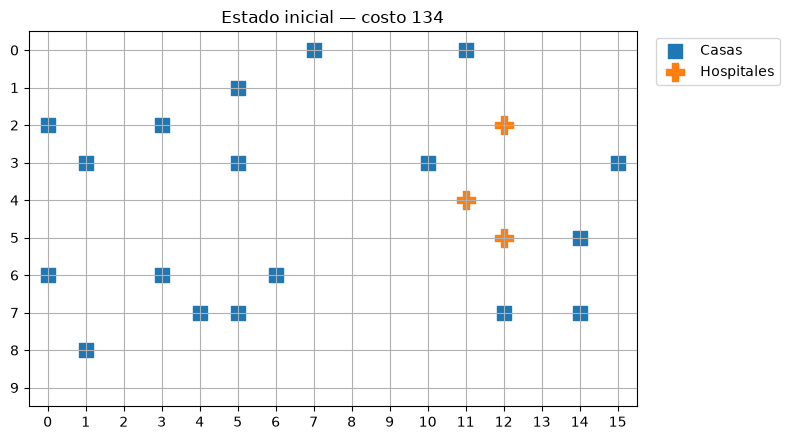

In [3]:
HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3

all_cells = [(r, c) for r in range(HEIGHT) for c in range(WIDTH)]
houses = set(random.sample(all_cells, NUM_HOUSES))
available = list(set(all_cells) - houses)
initial_hospitals = set(random.sample(available, NUM_HOSPITALS))

plot_state(HEIGHT, WIDTH, houses, initial_hospitals,
           title=f'Estado inicial — costo {total_cost(houses, initial_hospitals)}')

## 2. Vecindario

Para generar estados vecinos moveremos **un hospital a la vez** hacia una celda adyacente disponible.

In [4]:
def neighbors_of_state(height, width, houses, hospitals):
    neighbors = []
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors

neighbors = neighbors_of_state(HEIGHT, WIDTH, houses, initial_hospitals)
print('Número de vecinos:', len(neighbors))
print('Costo actual:', total_cost(houses, initial_hospitals))
print('Mejor costo vecino:', min(total_cost(houses, n) for n in neighbors))

Número de vecinos: 12
Costo actual: 134
Mejor costo vecino: 125


## 3. Hill Climbing

En cada iteración:

1. generamos todos los vecinos;
2. calculamos sus costos;
3. nos movemos al vecino con menor costo;
4. detenemos el proceso cuando ningún vecino mejora la solución.

Costo inicial: 134
Costo final: 62
Iteraciones con mejora: 13


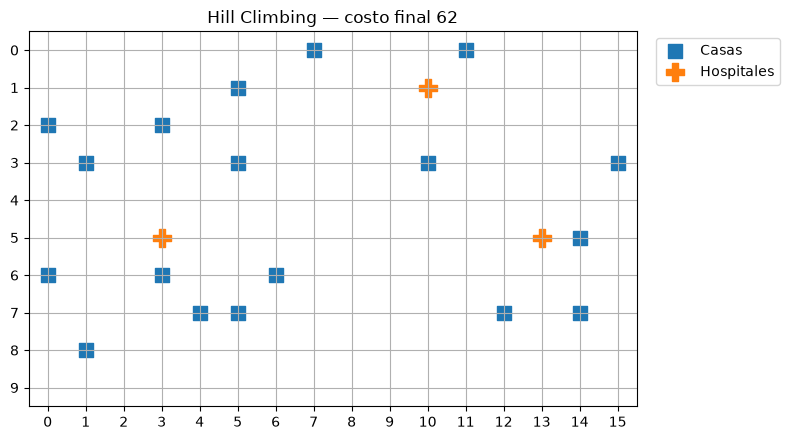

In [5]:
def hill_climbing(height, width, houses, num_hospitals, initial_state=None,
                  max_iterations=200, rng=None):
    rng = rng or random.Random()
    available = list(set((r, c) for r in range(height) for c in range(width)) - houses)
    current = set(initial_state) if initial_state is not None else set(rng.sample(available, num_hospitals))
    history = [total_cost(houses, current)]
    states = [set(current)]

    for _ in range(max_iterations):
        neighbors = neighbors_of_state(height, width, houses, current)
        if not neighbors:
            break

        costs = [total_cost(houses, n) for n in neighbors]
        best_cost = min(costs)
        current_cost = history[-1]

        if best_cost >= current_cost:
            break

        best_neighbors = [n for n, c in zip(neighbors, costs) if c == best_cost]
        current = set(rng.choice(best_neighbors))
        history.append(best_cost)
        states.append(set(current))

    return current, history, states

solution, history, states = hill_climbing(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals,
    rng=random.Random(SEED)
)

print('Costo inicial:', history[0])
print('Costo final:', history[-1])
print('Iteraciones con mejora:', len(history) - 1)
plot_state(HEIGHT, WIDTH, houses, solution,
           title=f'Hill Climbing — costo final {history[-1]}')

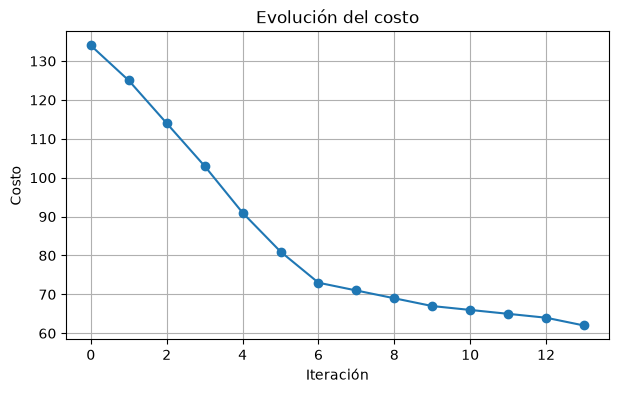

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(range(len(history)), history, marker='o')
plt.xlabel('Iteración')
plt.ylabel('Costo')
plt.title('Evolución del costo')
plt.grid(True)
plt.show()

## 4. Random Restart

Una corrida de Hill Climbing puede terminar en un óptimo local. Random Restart ejecuta el algoritmo desde diferentes estados iniciales y conserva la mejor solución encontrada.

Mejor costo: 56
Reinicio ganador: 2


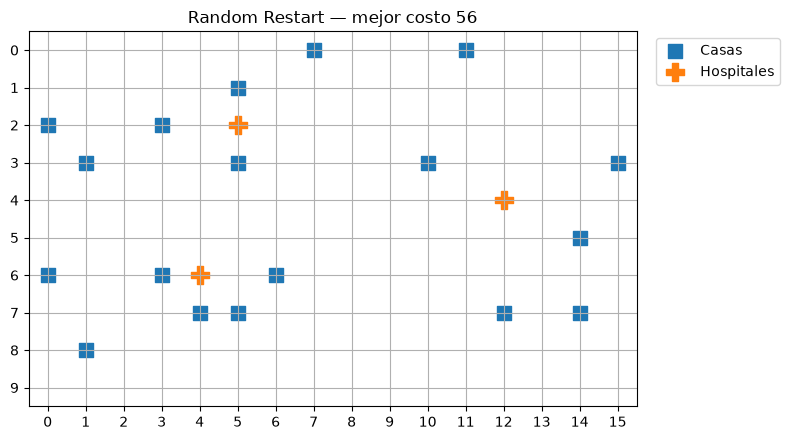

In [7]:
def random_restart(height, width, houses, num_hospitals, restarts=30, seed=0):
    master_rng = random.Random(seed)
    runs = []
    best = None

    for restart in range(restarts):
        run_seed = master_rng.randrange(10**9)
        solution, history, _ = hill_climbing(
            height, width, houses, num_hospitals,
            rng=random.Random(run_seed)
        )
        record = {
            'restart': restart,
            'solution': solution,
            'initial_cost': history[0],
            'final_cost': history[-1],
            'iterations': len(history) - 1
        }
        runs.append(record)
        if best is None or record['final_cost'] < best['final_cost']:
            best = record

    return best, runs

best, runs = random_restart(HEIGHT, WIDTH, houses, NUM_HOSPITALS, restarts=40, seed=SEED)
print('Mejor costo:', best['final_cost'])
print('Reinicio ganador:', best['restart'])
plot_state(HEIGHT, WIDTH, houses, best['solution'],
           title=f'Random Restart — mejor costo {best["final_cost"]}')

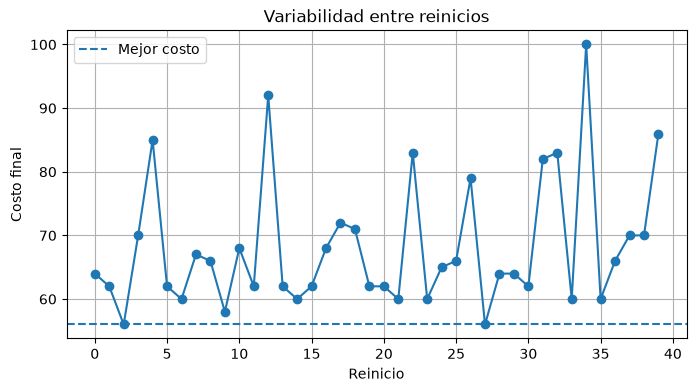

In [8]:
final_costs = [run['final_cost'] for run in runs]
plt.figure(figsize=(8, 4))
plt.plot(final_costs, marker='o')
plt.axhline(min(final_costs), linestyle='--', label='Mejor costo')
plt.xlabel('Reinicio')
plt.ylabel('Costo final')
plt.title('Variabilidad entre reinicios')
plt.legend()
plt.grid(True)
plt.show()

## Actividades

### Actividad 1 — Distancia euclídea

Modifica la función de costo para usar

$$
d(a,b)=\sqrt{(a_r-b_r)^2+(a_c-b_c)^2}
$$

Compara la ubicación de los hospitales y el costo con la distancia Manhattan.

Costo inicial (euclídeo): 111.2
Costo final (euclídeo): 46.7
Iteraciones con mejora: 17


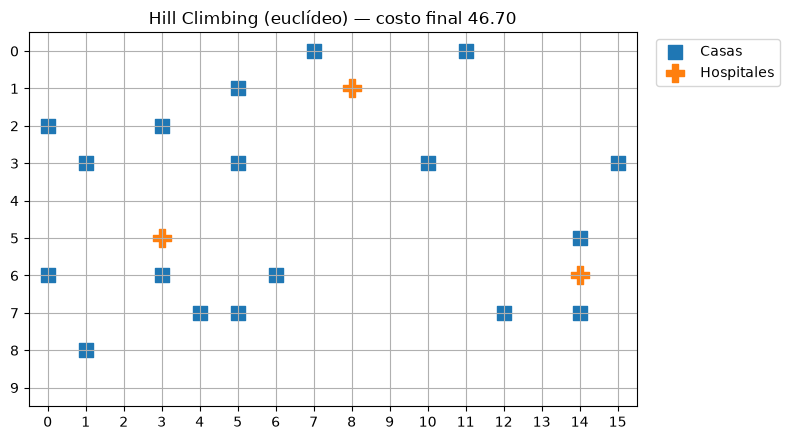

In [9]:
def euclidea(a, b):
    return ((a[0] - b[0])**2 + (a[1] - b[1])**2)**0.5

def total_euclidea(houses, hospitals):
    return sum(min(euclidea(house, hospital) for hospital in hospitals)
               for house in houses)

def hill_c(height, width, houses, num_hospitals, cost_fn, neighbor_fn=neighbors_of_state, initial_state=None, max_iterations=200, rng=None):
    rng = rng or random.Random()
    available = list(set((r, c) for r in range(height) for c in range(width)) - houses)
    current = set(initial_state) if initial_state is not None else set(rng.sample(available, num_hospitals))
    history = [cost_fn(houses, current)]
    states = [set(current)]

    for _ in range(max_iterations):
        neighbors = neighbor_fn(height, width, houses, current)
        if not neighbors:
            break

        costs = [cost_fn(houses, n) for n in neighbors]
        best_cost = min(costs)
        current_cost = history[-1]

        if best_cost >= current_cost:
            break

        best_neighbors = [n for n, c in zip(neighbors, costs) if c == best_cost]
        current = set(rng.choice(best_neighbors))
        history.append(best_cost)
        states.append(set(current))

    return current, history, states

solution_euc, history_euc, states_euc = hill_c(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    cost_fn=total_euclidea,
    initial_state=initial_hospitals,
    rng=random.Random(SEED)
)

print('Costo inicial (euclídeo):', round(history_euc[0], 2))
print('Costo final (euclídeo):', round(history_euc[-1], 2))
print('Iteraciones con mejora:', len(history_euc) - 1)

plot_state(HEIGHT, WIDTH, houses, solution_euc,
           title=f'Hill Climbing (euclídeo) — costo final {history_euc[-1]:.2f}')

In [10]:
# Los dos costos no están en la misma escala, así que medimos ambas soluciones con ambas métricas.
for nombre, sol in [('Manhattan', solution), ('Euclídea', solution_euc)]:
    print(f'{nombre:10s} -> Manhattan: {total_cost(houses, sol):3d}   '
          f'Euclídeo: {total_euclidea(houses, sol):6.2f}   '
          f'posiciones: {sorted(sol)}')

Manhattan  -> Manhattan:  62   Euclídeo:  48.24   posiciones: [(1, 10), (5, 3), (5, 13)]
Euclídea   -> Manhattan:  60   Euclídeo:  46.70   posiciones: [(1, 8), (5, 3), (6, 14)]


**Comparación**

| Solución | Costo Manhattan | Costo euclídeo | Posiciones |
|---|---|---|---|
| Manhattan | 62 | 48.24 | (1,10), (5,3), (5,13) |
| Euclídea | 60 | 46.70 | (1,8), (5,3), (6,14) |

Un hospital queda en la misma celda (5,3) y los otros dos se corren un par de casillas. El cambio es pequeño porque las casas están repartidas de forma parecida bajo las dos métricas: lo que cambia es cuánto pesa una casa lejana. La euclídea no penaliza tanto la diagonal, así que el hospital tiende a acercarse al centro geométrico del grupo en vez de alinearse en fila o columna.

Los costos finales no se pueden comparar entre sí (46.70 no es "mejor" que 62, son unidades distintas). Midiendo ambas soluciones con la misma métrica, la solución euclídea resulta ligeramente mejor incluso en Manhattan (60 vs 62): la corrida con Manhattan se quedó atrapada en un óptimo local. Con costos enteros hay muchos más empates y mesetas, mientras que la euclídea da valores continuos que casi nunca empatan y dejan una pendiente más clara para seguir bajando.

### Actividad 2 — Número de hospitales

Ejecuta Random Restart para $k\in\{1,2,3,4,5\}$. Registra el mejor costo y discute si agregar hospitales produce siempre la misma reducción.

In [11]:
resultado = []
for k in range(1, 6):
    best_k, _ = random_restart(HEIGHT, WIDTH, houses, k, restarts=40, seed=SEED)
    resultado.append((k, best_k['final_cost']))

anterior = None
for k, costo in resultado:
    reduccion = '' if anterior is None else f'{costo - anterior:+d}'
    print(f'k = {k}   mejor costo = {costo:3d}   {reduccion}')
    anterior = costo

k = 1   mejor costo = 114   
k = 2   mejor costo =  76   -38
k = 3   mejor costo =  56   -20
k = 4   mejor costo =  46   -10
k = 5   mejor costo =  38   -8


**Resultados**

| $k$ | Mejor costo | Reducción |
|---|---|---|
| 1 | 114 | — |
| 2 | 76 | −38 |
| 3 | 56 | −20 |
| 4 | 46 | −10 |
| 5 | 38 | −8 |

Agregar hospitales siempre baja el costo, pero cada vez menos: la reducción pasa de 38 a 8. No es la misma mejora en cada paso.

La razón es que el primer hospital tiene que atender a las 18 casas, incluidas las más alejadas, así que el segundo se lleva un bloque entero de casas que estaban pagando distancias grandes. A partir del tercero solo quedan casas que ya tienen un hospital relativamente cerca, y lo único que se gana es repartir mejor un grupo pequeño.

El costo nunca puede subir al agregar un hospital, porque la solución con $k$ hospitales sigue siendo válida con $k+1$ (el hospital extra no obliga a ninguna casa a alejarse). En el límite, con un hospital por casa el costo sería 0. Para decidir cuántos construir habría que meter el costo de construcción en la función objetivo, no solo la distancia.

### Actividad 3 — Diseño del vecindario

Actualmente un hospital solo se mueve una celda. Crea un vecindario que permita movimientos de hasta dos celdas. ¿Mejora el resultado? ¿Cuánto aumenta el número de vecinos evaluados?

Vecinos en el estado inicial
  1 paso:  12
  2 pasos: 31

Desde el mismo estado inicial
  1 paso:  62 en 13 iteraciones
  2 pasos: 60 en 9 iteraciones


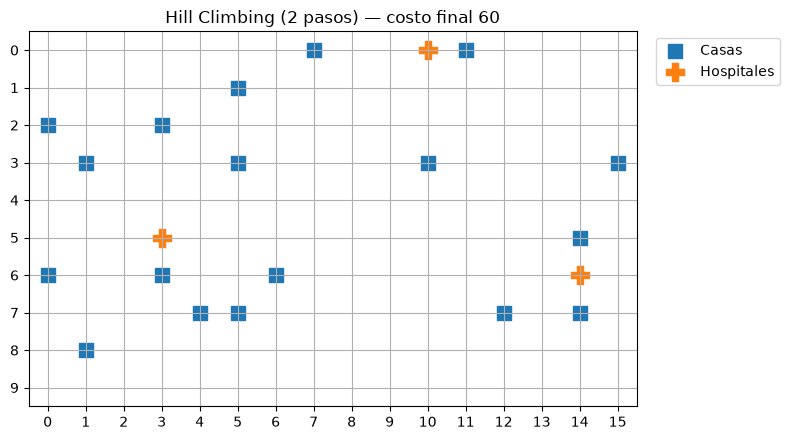


Con Random Restart (40 reinicios)
  1 paso : mejor 56   promedio 68.17   iteraciones promedio 7.55


  2 pasos: mejor 56   promedio 58.20   iteraciones promedio 7.22


In [12]:
def neighbors_of_state_2_steps(height, width, houses, hospitals):
    neighbors = []
    moves = [(dr, dc)
             for dr in range(-2, 3) for dc in range(-2, 3)
             if (dr or dc) and abs(dr) + abs(dc) <= 2]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors


def random_restart_generic(height, width, houses, num_hospitals,
                           neighbor_fn=neighbors_of_state, cost_fn=total_cost,
                           restarts=30, seed=0):
    master_rng = random.Random(seed)
    runs = []
    best = None

    for restart in range(restarts):
        run_seed = master_rng.randrange(10**9)
        solution, history, _ = hill_c(
            height, width, houses, num_hospitals,
            cost_fn=cost_fn, neighbor_fn=neighbor_fn,
            rng=random.Random(run_seed)
        )
        record = {
            'restart': restart,
            'solution': solution,
            'initial_cost': history[0],
            'final_cost': history[-1],
            'iterations': len(history) - 1
        }
        runs.append(record)
        if best is None or record['final_cost'] < best['final_cost']:
            best = record

    return best, runs


print('Vecinos en el estado inicial')
print('  1 paso: ', len(neighbors_of_state(HEIGHT, WIDTH, houses, initial_hospitals)))
print('  2 pasos:', len(neighbors_of_state_2_steps(HEIGHT, WIDTH, houses, initial_hospitals)))

sol_2, hist_2, _ = hill_c(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    cost_fn=total_cost, neighbor_fn=neighbors_of_state_2_steps,
    initial_state=initial_hospitals, rng=random.Random(SEED)
)

print('\nDesde el mismo estado inicial')
print('  1 paso: ', history[-1], 'en', len(history) - 1, 'iteraciones')
print('  2 pasos:', hist_2[-1], 'en', len(hist_2) - 1, 'iteraciones')

plot_state(HEIGHT, WIDTH, houses, sol_2,
           title=f'Hill Climbing (2 pasos) — costo final {hist_2[-1]}')

print('\nCon Random Restart (40 reinicios)')
for etiqueta, fn in [('1 paso ', neighbors_of_state), ('2 pasos', neighbors_of_state_2_steps)]:
    mejor, corridas = random_restart_generic(
        HEIGHT, WIDTH, houses, NUM_HOSPITALS, neighbor_fn=fn, restarts=40, seed=SEED
    )
    finales = [c['final_cost'] for c in corridas]
    promedio = sum(finales) / len(finales)
    iteraciones = sum(c['iterations'] for c in corridas) / len(corridas)
    print(f'  {etiqueta}: mejor {mejor["final_cost"]}   promedio {promedio:.2f}   '
          f'iteraciones promedio {iteraciones:.2f}')

**Resultados**

En el estado inicial se pasa de 12 a 31 vecinos. El conjunto de movimientos crece de 4 a 12 offsets por hospital (todos los $(dr,dc)$ con $|dr|+|dc|\le 2$), o sea 3× en el peor caso; aquí queda en 2.6× porque varios candidatos caen fuera de la cuadrícula o sobre una casa.

Desde el mismo estado inicial: 62 en 13 iteraciones con un paso, 60 en 9 iteraciones con dos. Mejora el costo y con menos iteraciones, pero cada iteración cuesta el triple de evaluaciones, así que en total se evalúan más estados.

Con Random Restart y 40 reinicios:

| Vecindario | Mejor costo | Costo promedio | Iteraciones promedio |
|---|---|---|---|
| 1 paso | 56 | 68.17 | 7.55 |
| 2 pasos | 56 | 58.20 | 7.22 |

Los dos llegan al mismo mejor costo (56), pero el promedio baja de 68.17 a 58.20: el vecindario amplio termina mucho más seguido cerca del óptimo. Tiene sentido, porque muchos óptimos locales del vecindario de un paso dejan de serlo cuando se puede saltar dos celdas, y en particular permite mover un hospital en diagonal, algo imposible en un solo paso sin pasar por un estado peor.

La conclusión práctica es que el vecindario amplio hace más confiable una corrida individual, mientras que los reinicios compensan un vecindario pobre a base de repetir. Si ya se usa Random Restart, la ganancia en el mejor costo desaparece y solo queda la mejora en el promedio; ampliar el vecindario indefinidamente acaba costando lo mismo que revisar todo el espacio de búsqueda.

## Preguntas de cierre

**1. ¿Por qué Hill Climbing no necesita construir todo el espacio de búsqueda?**

Porque solo mira el estado actual y sus vecinos inmediatos. Genera los vecinos, se queda con el mejor y descarta el resto, así que en memoria nunca hay más de un estado y su vecindario. En este problema el espacio completo tiene del orden de $\binom{142}{3} \approx 470{,}000$ estados y las corridas terminan evaluando unas pocas decenas.

**2. ¿El resultado depende del estado inicial?**

Sí. Cada estado inicial cae en una cuenca de atracción distinta y el algoritmo termina en el óptimo local de esa cuenca. En los 40 reinicios los costos finales van de 56 a 100 con el mismo conjunto de casas, y solo 2 de 40 alcanzaron 56.

**3. ¿Random Restart garantiza encontrar el óptimo global?**

No. Aumenta mucho la probabilidad de encontrarlo, pero con un número finito de reinicios no hay garantía: si un óptimo local tiene una cuenca grande, es fácil caer siempre ahí y nunca en la del óptimo global. Solo con infinitos reinicios la probabilidad tiende a 1, y aun así no habría forma de saber que el resultado es el óptimo global sin recorrer todo el espacio.

**4. ¿Qué información se pierde al conservar únicamente el mejor vecino?**

Se pierden los demás vecinos del paso actual, y con ellos dos cosas. Primero, los empates: cuando varios vecinos tienen el mismo costo, elegir uno descarta ramas que podían llevar a un óptimo mejor y no queda registro para volver a intentarlas. Segundo, y más importante, los vecinos que empeoran el costo, que muchas veces son el único camino hacia el óptimo global, porque para salir de un óptimo local hay que subir antes de volver a bajar. Tampoco se guarda de dónde se venía, así que no hay manera de retroceder. Esto es justamente lo que atacan variantes como simulated annealing (acepta movimientos peores con cierta probabilidad) o beam search (mantiene varios estados a la vez).